(ch:advanced)=
# 7. Advanced examples: Bayesian billiards and outliers

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* solve the "Bayesian billiards" problem, and explain why marginalizing over an unknown parameter gives a different (and correct) answer compared to plugging in its maximum-likelihood estimate;
* explain what sigma clipping does and why it is a procedure rather than a model;
* write down the likelihood of a *mixture model* for good and bad data points, sample its posterior with `emcee`, and compute the posterior probability that each point is an outlier.

This chapter accompanies the last part of Lecture 6 and Section 3 of Hogg et al. (2010). Both examples put together everything from the previous chapters: generative models, priors, marginalization and MCMC.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special
import emcee, corner

rng = np.random.default_rng(7)
np.random.seed(6)                        # emcee draws from numpy's global random state
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## 7.1 Bayesian billiards

### The game

Alice and Bob play a game in a casino; the first to reach 6 points wins. Colin, the croupier, rolls a ball on a billiard table that Alice and Bob cannot see, and puts a marker where it stops. He then rolls one ball per round: if it stops to the left of the marker, Alice gets a point, otherwise Bob does. The rolls are fair and uniform, so if the marker sits at a fraction $\theta$ of the table width, Alice wins each round with probability $\theta$ and Bob with probability $1-\theta$, and $\theta$ itself is uniformly distributed on $[0,1]$.

The game is at 5–3 for Alice. **What is the probability that Bob still wins?** (The thought experiment goes back to Bayes' 1763 essay; this version follows Eddy 2004 and VanderPlas 2014.)

### The plug-in answer

Bob needs three wins in a row. If we knew $\theta$ the answer would be $P(\text{Bob wins}\,|\,\theta) = (1-\theta)^3$. We do not know $\theta$, but we have data: $N_A = 5$ wins for Alice and $N_B = 3$ for Bob, a binomial experiment with maximum-likelihood estimate $\hat\theta = N_A/(N_A+N_B) = 5/8$. Plugging this in,

$$
P(\text{Bob wins}) \approx (1-\hat\theta)^3 = (3/8)^3 = 27/512 \approx 0.053 .
$$

This is what most people compute, and it is wrong. A first hint: if the score were 5–0, the same recipe gives $\hat\theta = 1$ and a probability of *zero* for Bob, while a comeback is clearly not impossible after only five rolls.

### The Bayesian answer

The plug-in answer ignores that $\theta$ is uncertain. Denote the data by $y = \{N_A=5, N_B=3\}$ and the event "Bob wins" by $W$. What we want is $P(W\,|\,y)$, and $\theta$ is a nuisance parameter that we must marginalize over (Chapter 3, Eq. {eq}`eq:marginalization`):

$$
P(W\,|\,y) = \int_0^1 P(W\,|\,\theta, y)\,p(\theta\,|\,y)\,d\theta = \int_0^1 (1-\theta)^3\,p(\theta\,|\,y)\,d\theta .
$$

The posterior density $p(\theta\,|\,y)$ follows from Bayes' theorem with the binomial likelihood $p(y\,|\,\theta) = \binom{8}{5}\theta^5(1-\theta)^3$ and the prior. Here we *know* the prior: Colin's first roll was uniform, so $p(\theta) = 1$ on $[0,1]$ (in general this is a Beta prior, Chapter 5). Hence $p(\theta\,|\,y) = p(y\,|\,\theta)\,p(\theta)/p(y)$ with the evidence $p(y) = \int_0^1 p(y\,|\,\theta)\,p(\theta)\,d\theta$, and

$$
P(W\,|\,y) = \frac{\int_0^1 (1-\theta)^3\,\theta^5(1-\theta)^3\,d\theta}{\int_0^1 \theta^5(1-\theta)^3\,d\theta} = \frac{\int_0^1 \theta^5(1-\theta)^6\,d\theta}{\int_0^1 \theta^5(1-\theta)^3\,d\theta} .
$$ (eq:billiards)

The binomial coefficients cancel. Integrals of this form are Beta functions, $\int_0^1 \theta^{r}(1-\theta)^{s}\,d\theta = B(r+1, s+1) = \frac{r!\,s!}{(r+s+1)!}$, so

$$
P(W\,|\,y) = \frac{5!\,6!/12!}{5!\,3!/9!} = \frac{6!\,9!}{3!\,12!} = \frac{120}{10\cdot11\cdot12} = \frac{1}{11} \approx 0.091 .
$$

Almost twice the plug-in answer. The difference is entirely due to marginalization: values of $\theta$ below $\hat\theta$ (favourable to Bob) contribute disproportionately, because $(1-\theta)^3$ grows quickly as $\theta$ decreases.

In [2]:
def comeback_bayes(n_win, n_B, n_A=None):
    """P(Bob wins | Alice has n_A = n_win-1 points, Bob has n_B) with a uniform prior on theta"""
    n_A = n_win - 1 if n_A is None else n_A
    n_needed = n_win - n_B                                          # rounds Bob must win in a row
    return special.beta(n_A + 1, n_B + n_needed + 1) / special.beta(n_A + 1, n_B + 1)

def comeback_plugin(n_win, n_B, n_A=None):
    n_A = n_win - 1 if n_A is None else n_A
    p_hat = n_A / (n_A + n_B)
    return (1 - p_hat)**(n_win - n_B)

print(f"score 5-3:  plug-in {comeback_plugin(6, 3):.4f}   Bayes {comeback_bayes(6, 3):.4f}   (exact: 1/11 = {1/11:.4f})")

score 5-3:  plug-in 0.0527   Bayes 0.0909   (exact: 1/11 = 0.0909)


### Check by simulation

A generative model can be simulated, so let's play a million games and count. The important subtlety: **each game must start with a new, uniformly drawn marker position $\theta$.** If we fix $\theta$ at some value (say $\hat\theta$) we simulate $P(W\,|\,\theta)$, not $P(W\,|\,y)$. The prior is part of the generative model.

In [3]:
n_win, n_B, n_A = 6, 3, 5
n_games = 1_000_000

theta = rng.uniform(size=n_games)                          # a new marker position for every game (the prior!)
rolls = rng.uniform(size=(2 * n_win - 1, n_games))         # at most 11 rolls decide a game
alice_count = np.cumsum(rolls < theta, axis=0)             # cumulative score after each roll
bob_count = np.cumsum(rolls >= theta, axis=0)

# games that pass through the score 5-3: after 8 rolls, Bob has 3 (and Alice 5)
good_games = bob_count[n_A + n_B - 1] == n_B
# ... of those, games where Bob then wins the next 3 rolls: after 11 rolls Bob has 6
bob_won = bob_count[n_A + n_B + (n_win - n_B) - 1][good_games] == n_win

print(f"games that reached 5-3: {good_games.sum()};  Bob came back in {bob_won.sum()} of them")
print(f"simulated P(Bob wins | 5-3) = {bob_won.mean():.4f}   (Bayes: {1/11:.4f}, plug-in: {27/512:.4f})")

games that reached 5-3: 111197;  Bob came back in 10114 of them
simulated P(Bob wins | 5-3) = 0.0910   (Bayes: 0.0909, plug-in: 0.0527)


The simulation agrees with the Bayesian calculation, not with the plug-in estimate. The same holds for every score:

In [4]:
print(" score  | simulation |  plug-in  |  Bayes")
for n_B in range(n_win - 1):
    n_needed = n_win - n_B
    good = bob_count[n_A + n_B - 1] == n_B
    won = bob_count[n_A + n_B + n_needed - 1][good] == n_win
    print(f"  5-{n_B}   |   {won.mean():.4f}   |  {comeback_plugin(n_win, n_B):.4f}   |  {comeback_bayes(n_win, n_B):.4f}")

 score  | simulation |  plug-in  |  Bayes
  5-0   |   0.0011   |  0.0000   |  0.0011
  5-1   |   0.0076   |  0.0001   |  0.0076
  5-2   |   0.0303   |  0.0067   |  0.0303
  5-3   |   0.0910   |  0.0527   |  0.0909
  5-4   |   0.2255   |  0.1975   |  0.2273


At 5–0 the plug-in answer is exactly zero, while in reality Bob still wins one game in a thousand.

```{admonition} The lesson
:class: important
Whenever a prediction depends on a parameter that is only estimated from data, plugging in the best-fit value and ignoring its uncertainty gives the wrong answer. Marginalizing over the parameter's posterior gives the right one. This is not a game-show curiosity: the same happens when you predict a light curve, extrapolate a fit, or compute a detection probability using best-fit parameters. Use posterior samples (Chapter 6) and propagate them.
```

## 7.2 Outliers, part 1: sigma clipping

Real data contain **outliers**: points that are much farther from the model than their uncertainties allow, because of unmodelled experimental problems, rare noise sources, or because the model does not apply to all the data. Least-squares fits are very sensitive to them, since a single point at $10\sigma$ contributes $100$ to $\chi^2$. Selecting outliers by hand is subjective and irreproducible. The traditional automatic alternative in astronomy is **sigma clipping**: compute the median and standard deviation of the residuals, discard all points more than $n\sigma$ from the median, recompute, and iterate until nothing changes.

In [5]:
def sigma_clip(residuals, n_sigma=3.0, max_iter=20):
    """iterative sigma clipping; returns a boolean mask of the points that survive"""
    keep = np.ones(len(residuals), dtype=bool)
    for _ in range(max_iter):
        med, std = np.median(residuals[keep]), np.std(residuals[keep])
        new_keep = np.abs(residuals - med) < n_sigma * std
        if np.array_equal(new_keep, keep):
            break
        keep = new_keep
    return keep

# a sample with 5% outliers
r = np.concatenate([rng.normal(0, 1, 190), rng.normal(0, 8, 10)])
keep = sigma_clip(r)
print(f"kept {keep.sum()} of {len(r)} points; std before {np.std(r):.2f}, after {np.std(r[keep]):.2f}")

kept 192 of 200 points; std before 1.66, after 0.95


Sigma clipping is simple and often adequate, but note what it is: a *procedure*, not the outcome of a statistical model. The threshold $n$ is arbitrary; the result depends on the order of operations; a heavy-tailed but perfectly valid noise distribution gets clipped; and the clipped points are simply thrown away, with no statement about how confident we are that they are bad. Hogg et al. (2010) put it bluntly: it is "a procedure and not the outcome of justifiable modeling."

## 7.3 Outliers, part 2: a mixture model

The Bayesian alternative is to *model* the outliers. Following Hogg et al. (2010, Section 3) we fit a straight line $m(x,\theta) = a + b x$, $\theta = (a, b)$, to data with known uncertainties $\sigma_{y,i}$ and build a generative model that produces the bad points as well as the good ones. (Hogg et al. write the line as $m x + b$ and call the outlier parameters $P_b$, $Y_b$ and $V_b$; we use $P_{\rm bad}$, $\mu_{\rm bad}$ and $\tau_{\rm bad}^2$ for the same three quantities, in the spirit of the hyperparameter notation of Chapter 5.)

### The generative model

Every point is either *good* (foreground), drawn from the line with its Gaussian uncertainty, or *bad* (background), drawn from some broad distribution that we do not know much about. We describe the background by a Gaussian with mean $\mu_{\rm bad}$ and standard deviation $\tau_{\rm bad}$ (in $y$), and we let each point be bad with prior probability $P_{\rm bad}$. These three numbers are **hyperparameters** in the sense of the box in Chapter {ref}`5 <sec:hyperparameters>`: they describe the *population* of bad points, not the line we are after, and we will marginalize over them in the end. Introduce for every point a binary flag $q_i$ ($1$ = good, $0$ = bad). The likelihood is then

$$
\mathcal{L} = \prod_{i=1}^{N}\Big[p_{\rm fg}(y_i\,|\,a,b)\Big]^{q_i}\Big[p_{\rm bg}(y_i\,|\,\mu_{\rm bad}, \tau_{\rm bad})\Big]^{1-q_i} ,
$$

with the foreground (good-point) distribution

$$
p_{\rm fg}(y_i\,|\,a, b) = \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}}\exp\left(-\frac{[y_i - a - b x_i]^2}{2\sigma_{y,i}^2}\right)
$$ (eq:fg)

and the background (bad-point) distribution

$$
p_{\rm bg}(y_i\,|\,\mu_{\rm bad}, \tau_{\rm bad}) = \frac{1}{\sqrt{2\pi[\tau_{\rm bad}^2 + \sigma_{y,i}^2]}}\exp\left(-\frac{[y_i - \mu_{\rm bad}]^2}{2[\tau_{\rm bad}^2 + \sigma_{y,i}^2]}\right) ,
$$ (eq:bg)

in which the background variance adds to the measurement variance. The prior on the flags is binomial: $p(\{q_i\}\,|\,P_{\rm bad}) = \prod_i (1-P_{\rm bad})^{q_i}P_{\rm bad}^{1-q_i}$. The model now has $N + 5$ parameters, $\{a, b, P_{\rm bad}, \mu_{\rm bad}, \tau_{\rm bad}, q_1, \dots, q_N\}$, which sounds like madness. But the $q_i$ are nuisance parameters, and marginalizing over them can be done with pen and paper. The result is

$$
\mathcal{L} = \prod_{i=1}^{N}\Big[(1-P_{\rm bad})\,p_{\rm fg}(y_i\,|\,a,b) + P_{\rm bad}\,p_{\rm bg}(y_i\,|\,\mu_{\rm bad},\tau_{\rm bad})\Big] ,
$$ (eq:mixture)

the likelihood with the $q_i$ summed out (and the prior on the $q_i$ absorbed). The derivation, which uses nothing more than the law of total probability and the fact that both the likelihood and the prior factorize over the data points, is written out in {ref}`Appendix A <app:mixture>`; it also explains how the $2^N$ possible flag combinations collapse into $N$ two-term sums.

Each point is now drawn from a **mixture** of the foreground and the background distribution, with mixing weights $1-P_{\rm bad}$ and $P_{\rm bad}$. This leaves five parameters (two of the line, three hyperparameters), which is easy work for `emcee`.

Why a Gaussian for the outliers, of which we know so little? Because we do not need an *accurate* model of the bad points, only *a* model, and the Gaussian is the least restrictive choice given that we let its mean and width float (it is the maximum-entropy distribution with a given mean and variance). If you do know how your outliers are generated, use that instead.

### Priors and sampling

Flat priors on $a$ and $b$; $P_{\rm bad}$ flat on $[0, 1]$; $\mu_{\rm bad}$ flat over the range of the data; and $\tau_{\rm bad}$ flat in $\ln\tau_{\rm bad}$, because a width is a scale parameter that may range over orders of magnitude (Chapter 5). (Priors on hyperparameters are sometimes called *hyperpriors*.) We apply the model to the full Hogg et al. dataset, including points 1–4, which a naive least-squares fit to all 20 points takes seriously (it gives a slope of $1.08 \pm 0.08$, Figure 2 of Hogg et al.) even though they are obviously off the relation.

In [6]:
hogg = np.genfromtxt("data/hogg_table1.csv", delimiter=",", names=True)
x, y, sy = hogg["x"], hogg["y"], hogg["sigma_y"]

def log_likelihood_mixture(theta, x, y, sy):
    a, b, P_bad, mu_bad, ln_tau_bad = theta
    var_bad = np.exp(2 * ln_tau_bad)                 # tau_bad^2
    log_fg = -0.5 * np.log(2 * np.pi * sy**2) - 0.5 * (y - a - b * x)**2 / sy**2
    log_bg = -0.5 * np.log(2 * np.pi * (var_bad + sy**2)) - 0.5 * (y - mu_bad)**2 / (var_bad + sy**2)
    # log of the mixture, computed stably with logaddexp
    return np.sum(np.logaddexp(np.log(1 - P_bad) + log_fg, np.log(P_bad) + log_bg))

def log_prior_mixture(theta):
    a, b, P_bad, mu_bad, ln_tau_bad = theta
    if (-500 < a < 500) and (-5 < b < 5) and (0 < P_bad < 1) and (0 < mu_bad < 1000) and (np.log(1) < ln_tau_bad < np.log(1e3)):
        return 0.0
    return -np.inf

def log_posterior_mixture(theta, x, y, sy):
    lp = log_prior_mixture(theta)
    return lp + log_likelihood_mixture(theta, x, y, sy) if np.isfinite(lp) else -np.inf

n_walkers, n_dim = 40, 5
p0 = np.array([30.0, 2.0, 0.2, 400.0, np.log(100.0)]) + 1e-3 * rng.normal(size=(n_walkers, n_dim))   # (a, b, P_bad, mu_bad, ln tau_bad)
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior_mixture, args=(x, y, sy))
sampler.run_mcmc(p0, 6000, progress=False)
tau = sampler.get_autocorr_time(quiet=True)
burn = int(3 * tau.max())
print(f"autocorrelation times: {np.round(tau)}; discarding the first {burn} steps as burn-in")

autocorrelation times: [62. 66. 59. 72. 65.]; discarding the first 216 steps as burn-in


Before we look at the result, we follow the checklist of Chapter 6 and inspect the walkers. This posterior has a second, much less probable mode in which *all* points are declared outliers ($P_{\rm bad} \to 1$) and the line is meaningless; a walker that wanders into it stays there. We identify such rogue walkers by their log-posterior, which is far below that of the rest of the ensemble, and drop them.

In [7]:
log_prob = sampler.get_log_prob(discard=burn)                  # shape (n_steps, n_walkers)
walker_median = np.median(log_prob, axis=0)
ok = walker_median > np.median(walker_median) - 10             # walkers stuck at a log-posterior 10 below the ensemble median
print(f"{np.sum(~ok)} of {n_walkers} walkers are stuck in the 'everything is an outlier' mode and are discarded")

chain = sampler.get_chain(discard=burn, thin=int(tau.max() / 2))[:, ok, :]
samples = chain.reshape(-1, n_dim)
print(f"{len(samples)} samples after burn-in, thinning and removing rogue walkers")

1 of 40 walkers are stuck in the 'everything is an outlier' mode and are discarded
6240 samples after burn-in, thinning and removing rogue walkers


a    =  32.639 -19.755 +19.040
b    =   2.253 -0.112 +0.121
P_bad =   0.281 -0.114 +0.142


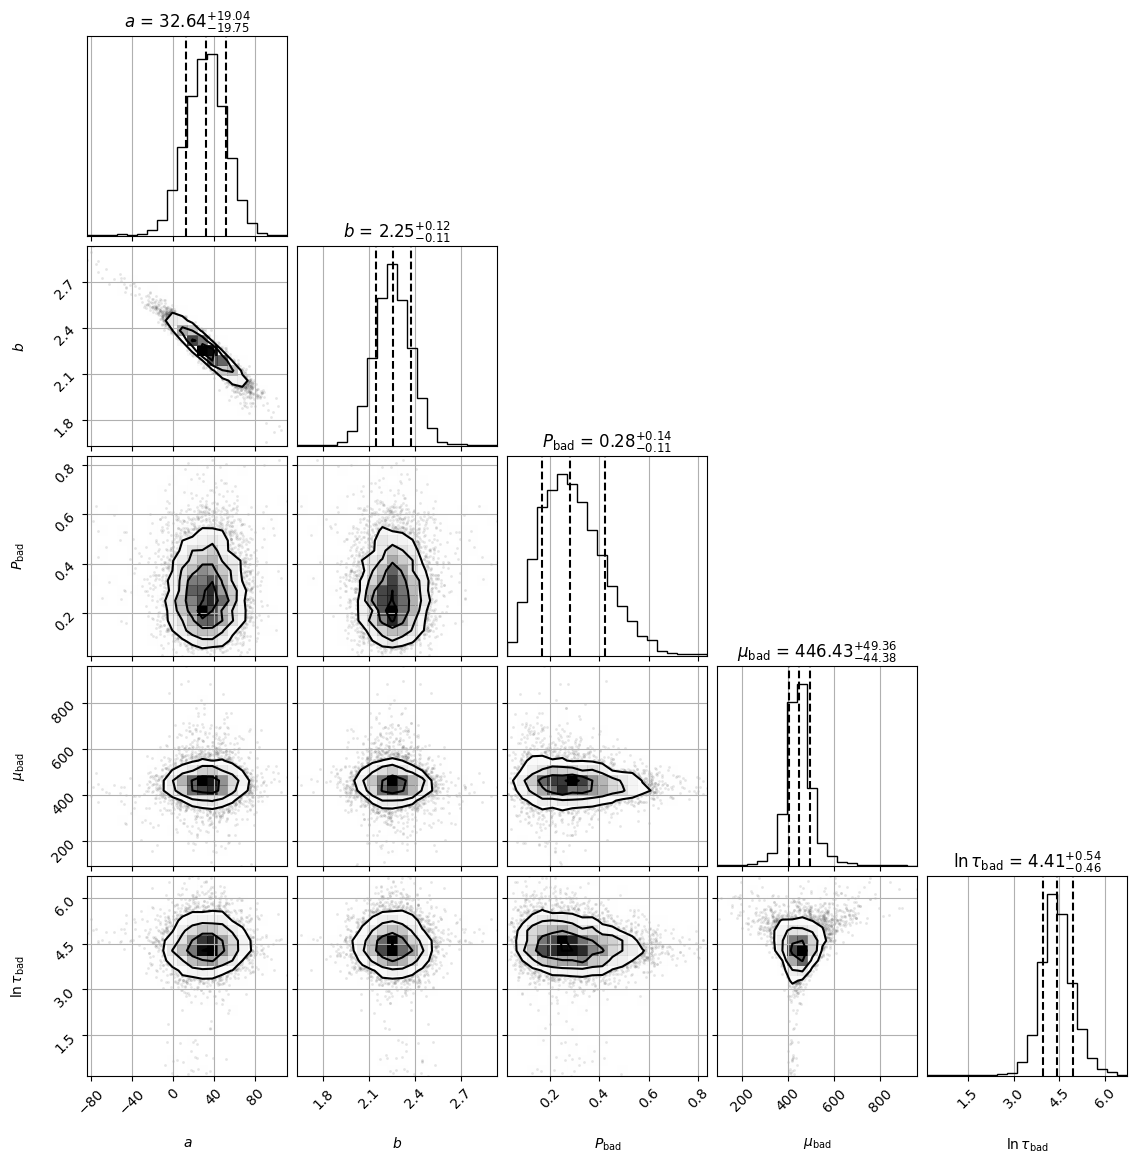

In [8]:
labels = [r"$a$", r"$b$", r"$P_{\rm bad}$", r"$\mu_{\rm bad}$", r"$\ln \tau_{\rm bad}$"]
fig = corner.corner(samples, labels=labels, quantiles=[0.159, 0.5, 0.841], show_titles=True, title_fmt=".2f")

for i, name in enumerate(["a", "b", "P_bad"]):
    lo, med, hi = np.percentile(samples[:, i], [15.9, 50, 84.1])
    print(f"{name:4s} = {med:7.3f} -{med-lo:.3f} +{hi-med:.3f}")

The marginal posterior for the slope is $b \approx 2.25 \pm 0.12$, consistent with the fit to the clean points only (Chapter 1: $2.24 \pm 0.11$) and nothing like the naive fit to all points. The posterior of $P_{\rm bad}$ says that roughly a quarter of the points are outliers, with a large uncertainty (there are only 20 points), and $\mu_{\rm bad}$ and $\tau_{\rm bad}$ are poorly constrained; they are nuisance (hyper)parameters and we do not care. Note how the posteriors of $a$ and $b$ are strongly *anti-correlated* (a steeper line needs a lower intercept): a good reason to always look at the joint distribution.

### Which points are the outliers?

The model tells us. For a given parameter vector, the posterior probability that point $i$ is bad follows from Bayes' theorem applied to the two branches of the mixture,

$$
P(q_i = 0\,|\,y_i, \theta) = \frac{P_{\rm bad}\,p_{\rm bg}(y_i)}{(1-P_{\rm bad})\,p_{\rm fg}(y_i) + P_{\rm bad}\,p_{\rm bg}(y_i)} ,
$$ (eq:outlier-prob)

and averaging this over the posterior samples marginalizes over the parameters (see {ref}`Appendix A <app:mixture>` for where this expression comes from).

outlier probability of points 1-4: [0.27 1.   1.   1.  ]


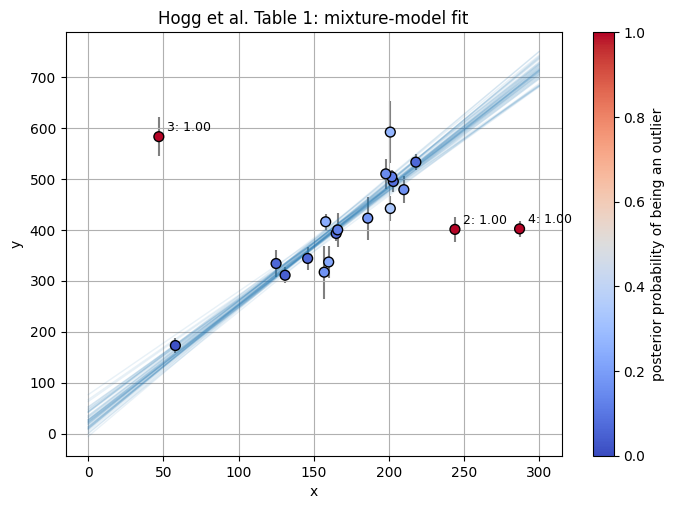

In [9]:
def prob_bad(theta, x, y, sy):
    a, b, P_bad, mu_bad, ln_tau_bad = theta
    tau_bad = np.exp(ln_tau_bad)
    fg = (1 - P_bad) * stats.norm.pdf(y, a + b * x, sy)
    bg = P_bad * stats.norm.pdf(y, mu_bad, np.sqrt(tau_bad**2 + sy**2))
    return bg / (fg + bg)

p_bad = np.mean([prob_bad(th, x, y, sy) for th in samples[::10]], axis=0)

fig, ax = plt.subplots(figsize=(8, 5.5))
xx = np.linspace(0, 300, 10)
for th in samples[rng.integers(0, len(samples), 50)]:
    ax.plot(xx, th[0] + th[1] * xx, color="C0", alpha=0.1, lw=1)          # 50 posterior draws of the line
sc = ax.errorbar(x, y, sy, fmt="none", ecolor="gray", zorder=1)
sc = ax.scatter(x, y, c=p_bad, cmap="coolwarm", vmin=0, vmax=1, s=50, zorder=2, edgecolor="k")
for xi, yi, idi, pb in zip(x, y, hogg["id"], p_bad):
    if pb > 0.5:
        ax.annotate(f"{int(idi)}: {pb:.2f}", (xi, yi), textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.colorbar(sc, label="posterior probability of being an outlier")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Hogg et al. Table 1: mixture-model fit");
print("outlier probability of points 1-4:", np.round(p_bad[:4], 2))

Points 2, 3 and 4 are flagged as outliers with certainty and the lines drawn from the posterior ignore them *without anyone having removed them*. Point 1 is instructive: it lies far above the line, but its uncertainty is large, so the model considers it a plausible foreground point and gives it an intermediate probability. Compare with sigma clipping, which would either keep or discard point 1 depending on the threshold: here every point gets a probability, the threshold is not arbitrary, the answer is reproducible, and a point in the grey zone contributes to the fit in proportion to its probability of being good. The price is a prior and an MCMC run, which by now is no price at all.

### Frequentist and Bayesian outlier rejection compared

Sigma clipping (frequentist, or rather: procedural) is simple, fast and needs no prior; it assumes Gaussian residuals and a fixed threshold, discards data irreversibly, and cannot quantify how bad a point is. The mixture model (Bayesian) needs a prior and a sampler; in return it uses all the data, it marginalizes over the outlier population, and it yields a posterior probability for every point and honest uncertainties for the parameters that include our ignorance about which points are bad. When the outliers are few and blatant, both give the same line. When they are many or subtle, only the mixture model tells you what is going on.

## 7.4 Test yourself

````{admonition} Q1. A radioactive mixture (practice exam)
:class: tip
For an isotope with lifetime $\tau$ the probability of a decay at time $t$ is $p(t\,|\,\tau) \propto e^{-t/\tau}$. We record the arrival times $t_1, \dots, t_n$ of decays from a barrel that may contain two isotopes with known lifetimes $\tau_a$ and $\tau_b$; a fraction $f_a$ of the mixture has lifetime $\tau_a$. The experiment runs from $t=0$ to $t = 1000$ s.

1. Normalize $p(t\,|\,\tau)$ such that its integral over the experiment equals one.
2. Write down the likelihood for decays from a single isotope, in $p(\cdot\,|\,\cdot)$ notation.
3. Write down the likelihood if the barrel contains the mixture.
4. We want to know whether the barrel contains the second isotope. (a) Formulate a null hypothesis and explain in words how you would compute a $p$-value. (b) Instead, approach this with parameter inference: which parameter do you measure, and how?

```{admonition} Answer
:class: dropdown
1. $\int_0^{1000} A e^{-t/\tau}dt = A\tau(1 - e^{-1000/\tau}) = 1$, so $p(t\,|\,\tau) = \dfrac{e^{-t/\tau}}{\tau\,(1 - e^{-1000/\tau})}$.
2. Independent decays: $p(\{t_i\}\,|\,\tau_a) = \prod_{i=1}^n p(t_i\,|\,\tau_a) = \left[\tau_a(1-e^{-1000/\tau_a})\right]^{-n} e^{-\sum_i t_i/\tau_a}$.
3. Each decay comes from a mixture: $p(t_i\,|\,\tau_a,\tau_b,f_a) = f_a\,p(t_i\,|\,\tau_a) + (1-f_a)\,p(t_i\,|\,\tau_b)$, and the likelihood is $\prod_i \left[f_a\,p(t_i\,|\,\tau_a) + (1-f_a)\,p(t_i\,|\,\tau_b)\right]$; it does not simplify further. This is exactly the structure of Eq. {eq}`eq:mixture`.
4. (a) $H_0$: the barrel contains only isotope $a$ ($f_a = 1$). Test statistic: the likelihood of the data under $H_0$ (or the likelihood ratio between $f_a=1$ and the best-fit $f_a$). Simulate many datasets of $n$ arrival times from $p(t\,|\,\tau_a)$ (the generative model with $f_a=1$), compute the statistic for each, and take as $p$-value the fraction of simulations with a statistic more extreme (lower likelihood) than observed. (b) Measure $f_a$: with a flat prior on $[0,1]$, obtain the posterior $p(f_a\,|\,\{t_i\}) \propto \mathcal{L}(f_a)$ on a grid (one parameter) or with MCMC, and report a credible interval. If the 95% interval excludes $f_a = 1$, there is evidence for the second isotope, and the interval also tells you how much of it there is.
```
````

````{admonition} Q2. The plug-in trap
:class: tip
You have fitted a light curve and obtained posterior samples of the decay time $\tau$. A colleague computes the probability that the source is still detectable after two years by plugging the median $\tau$ into the model. Explain in two sentences what is wrong and what to do instead.

```{admonition} Answer
:class: dropdown
The probability of detection depends non-linearly on $\tau$, so evaluating it at a single value ignores the uncertainty in $\tau$ and is biased, exactly like the plug-in estimate in Bayesian billiards. Compute the detection probability for each posterior sample of $\tau$ and average (marginalize) over the samples.
```
````

## Sources and further reading

* Hogg, Bovy & Lang (2010), [arXiv:1008.4686](https://arxiv.org/abs/1008.4686), Section 3 (pruning outliers) and Section 5 (non-Gaussian uncertainties).
* Foreman-Mackey (2014), [*Mixture models*](https://dfm.io/posts/mixture-models/), a blog post implementing the Hogg et al. model with `emcee`, including the per-point outlier probabilities.
* Eddy (2004), *What is Bayesian statistics?*, Nature Biotechnology 22, 1177, [doi:10.1038/nbt0904-1177](https://doi.org/10.1038/nbt0904-1177), the source of the billiards example.
* VanderPlas (2014), [*Frequentism and Bayesianism II: When results differ*](http://jakevdp.github.io/blog/2014/06/06/frequentism-and-bayesianism-2-when-results-differ/), for the vectorized simulation of the billiards game.
* Gelman et al. (2013), *Bayesian Data Analysis* (3rd ed.), [free PDF](https://sites.stat.columbia.edu/gelman/book/BDA3.pdf), Section 2.1 for Bayes' original problem and Chapter 17 for robust (mixture and heavy-tailed) models.